
# FD01 — Forest Disturbance Data Inspection

## Project
Satellite-Based Multi-Hazard Intelligence System

## Objective
Inspect a publicly available satellite-derived forest-change dataset,
understand its spatial and temporal coverage, examine its data values,
and identify limitations before selecting a detection method.

## Dataset
Hansen Global Forest Change, version GFC-2023-v1.11.

Official dataset source:
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2023-v1.11/download.html

## Data Layers
- treecover2000: estimated tree canopy cover in 2000, expressed as a percentage.
- lossyear: encoded year of detected forest loss.
- datamask: distinguishes no-data, mapped land and persistent water.

## Research Questions
1. What years of forest loss are represented in the selected tile?
2. How is forest loss distributed spatially?
3. What limitations must be considered before using forest-loss labels?
4. What further data are needed to investigate forest disturbance?

## Important Boundary
Forest loss is not automatically proof of illegal deforestation or human
activity. Natural disturbances, classification errors and other factors
must be considered. This inspection does not establish model accuracy
or a new research contribution.

## Workflow
Dataset access → metadata inspection → value analysis → visualization
→ quality checks → research observations.

In [1]:

# FD01 Cell 2 — Setup

import os
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio

from rasterio.enums import Resampling

BASE_DIR = "/content/forest_disturbance"
DATA_DIR = os.path.join(BASE_DIR, "data")
RESULTS_DIR = os.path.join(BASE_DIR, "results")

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("FD01 environment initialized.")
print("Data directory:", DATA_DIR)
print("Results directory:", RESULTS_DIR)
print("Rasterio version:", rasterio.__version__)

FD01 environment initialized.
Data directory: /content/forest_disturbance/data
Results directory: /content/forest_disturbance/results
Rasterio version: 1.5.2


In [2]:

# FD01 Cell 3 — Download two required raster layers

BASE_URL = (
    "https://storage.googleapis.com/"
    "earthenginepartners-hansen/GFC-2023-v1.11/"
)

FILES = {
    "lossyear": "Hansen_GFC-2023-v1.11_lossyear_20N_080E.tif",
    "treecover2000": "Hansen_GFC-2023-v1.11_treecover2000_20N_080E.tif",
}

def download_file(filename):
    url = BASE_URL + filename
    path = os.path.join(DATA_DIR, filename)

    if os.path.exists(path) and os.path.getsize(path) > 0:
        print("Already downloaded:", filename)
        return path

    print("Checking:", filename, flush=True)
    response = requests.get(url, stream=True, timeout=(20, 180))
    response.raise_for_status()

    total = int(response.headers.get("content-length", 0))
    downloaded = 0

    with open(path, "wb") as f:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)
                downloaded += len(chunk)

                if total:
                    print(
                        f"\rDownloaded {downloaded / 1e6:.1f}/"
                        f"{total / 1e6:.1f} MB",
                        end="",
                        flush=True
                    )

    print("\nSaved:", path)
    return path

paths = {}

for layer, filename in FILES.items():
    try:
        paths[layer] = download_file(filename)
    except Exception as e:
        print(f"\nCould not download {layer}: {e}")
        print("Stop here and send me the exact error.")
        raise

print("\nBoth raster layers are ready.")

Checking: Hansen_GFC-2023-v1.11_lossyear_20N_080E.tif
Downloaded 19.2/19.2 MB
Saved: /content/forest_disturbance/data/Hansen_GFC-2023-v1.11_lossyear_20N_080E.tif
Checking: Hansen_GFC-2023-v1.11_treecover2000_20N_080E.tif
Downloaded 88.1/88.1 MB
Saved: /content/forest_disturbance/data/Hansen_GFC-2023-v1.11_treecover2000_20N_080E.tif

Both raster layers are ready.


In [3]:

# FD01 Cell 4 — Metadata inspection

metadata_rows = []

for layer, path in paths.items():
    with rasterio.open(path) as src:
        row = {
            "layer": layer,
            "width": src.width,
            "height": src.height,
            "bands": src.count,
            "dtype": str(src.dtypes[0]),
            "CRS": str(src.crs),
            "nodata": src.nodata,
            "bounds": str(src.bounds),
            "resolution": str(src.res)
        }
        metadata_rows.append(row)

        print("\nLayer:", layer)
        for key, value in row.items():
            if key != "layer":
                print(f"{key}: {value}")

metadata_df = pd.DataFrame(metadata_rows)
metadata_df.to_csv(
    os.path.join(RESULTS_DIR, "FD01_raster_metadata.csv"),
    index=False
)

print("\nMetadata saved.")


Layer: lossyear
width: 40000
height: 40000
bands: 1
dtype: uint8
CRS: EPSG:4326
nodata: None
bounds: BoundingBox(left=80.0, bottom=10.0, right=90.0, top=20.0)
resolution: (0.00025, 0.00025)

Layer: treecover2000
width: 40000
height: 40000
bands: 1
dtype: uint8
CRS: EPSG:4326
nodata: None
bounds: BoundingBox(left=80.0, bottom=10.0, right=90.0, top=20.0)
resolution: (0.00025, 0.00025)

Metadata saved.


In [4]:

# FD01 Cell 5 — Sampled raster statistics

sampled_layers = {}

for layer, path in paths.items():
    with rasterio.open(path) as src:
        sample = src.read(
            1,
            out_shape=(1000, 1000),
            resampling=Resampling.nearest
        )

        sampled_layers[layer] = sample

        valid = sample if src.nodata is None else sample[sample != src.nodata]

        print(f"\n{layer}")
        print("Sample shape:", sample.shape)
        print("Data type:", sample.dtype)
        print("Sampled pixels:", sample.size)
        print("Unique values in sample:", len(np.unique(sample)))
        print("Minimum:", int(valid.min()) if valid.size else "No valid values")
        print("Maximum:", int(valid.max()) if valid.size else "No valid values")
        print("Mean:", round(float(valid.mean()), 3) if valid.size else "No valid values")
        print("NoData metadata value:", src.nodata)


lossyear
Sample shape: (1000, 1000)
Data type: uint8
Sampled pixels: 1000000
Unique values in sample: 24
Minimum: 0
Maximum: 23
Mean: 0.05
NoData metadata value: None

treecover2000
Sample shape: (1000, 1000)
Data type: uint8
Sampled pixels: 1000000
Unique values in sample: 101
Minimum: 0
Maximum: 100
Mean: 2.307
NoData metadata value: None


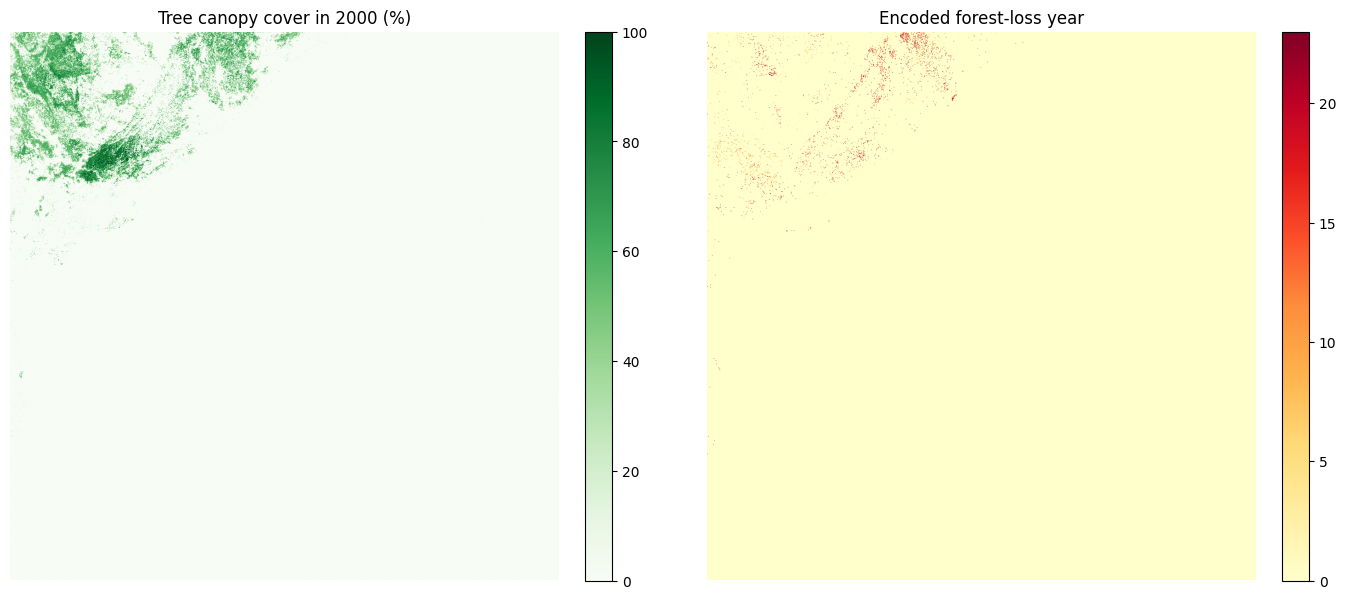

Figure saved: /content/forest_disturbance/results/FD01_forest_layers.png


In [5]:

# FD01 Cell 6 — Visual inspection

lossyear = sampled_layers["lossyear"]
treecover = sampled_layers["treecover2000"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im0 = axes[0].imshow(treecover, cmap="Greens", vmin=0, vmax=100)
axes[0].set_title("Tree canopy cover in 2000 (%)")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(lossyear, cmap="YlOrRd", vmin=0, vmax=23)
axes[1].set_title("Encoded forest-loss year")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()

figure_path = os.path.join(
    RESULTS_DIR, "FD01_forest_layers.png"
)
plt.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()

print("Figure saved:", figure_path)

In [6]:

# FD01 Cell 7 — Loss-year distribution in the sampled overview

lossyear = sampled_layers["lossyear"]

values, counts = np.unique(lossyear, return_counts=True)

distribution = pd.DataFrame({
    "encoded_value": values.astype(int),
    "sampled_pixel_count": counts.astype(int)
})

distribution["interpretation"] = distribution["encoded_value"].apply(
    lambda x: "No detected loss" if x == 0
    else f"Loss year: {2000 + x}"
)

display(distribution)

distribution.to_csv(
    os.path.join(RESULTS_DIR, "FD01_loss_year_distribution.csv"),
    index=False
)

print("\nSampled pixels:", int(counts.sum()))
print("Pixels with encoded loss year > 0:", int(lossyear[lossyear > 0].size))
print("Note: these counts are from a downsampled overview, not full-resolution totals.")

,encoded_value,sampled_pixel_count,interpretation
0,0,996560,No detected loss
1,1,55,Loss year: 2001
2,2,60,Loss year: 2002
3,3,76,Loss year: 2003
4,4,77,Loss year: 2004
5,5,85,Loss year: 2005
6,6,91,Loss year: 2006
7,7,117,Loss year: 2007
8,8,137,Loss year: 2008
9,9,169,Loss year: 2009



Sampled pixels: 1000000
Pixels with encoded loss year > 0: 3440
Note: these counts are from a downsampled overview, not full-resolution totals.


In [7]:

# FD01 Cell 8 — Basic quality checks

with rasterio.open(paths["lossyear"]) as loss_src, \
     rasterio.open(paths["treecover2000"]) as cover_src:

    print("Same dimensions:",
          (loss_src.width, loss_src.height) ==
          (cover_src.width, cover_src.height))

    print("Same CRS:", loss_src.crs == cover_src.crs)
    print("Same transform:", loss_src.transform == cover_src.transform)
    print("Same bounds:", loss_src.bounds == cover_src.bounds)

loss_values = np.unique(sampled_layers["lossyear"])
cover_values = np.unique(sampled_layers["treecover2000"])

print("\nUnique sampled loss-year values:", loss_values[:40])
print("Unique sampled tree-cover values:", cover_values[:40])

if np.any((lossyear < 0) | (lossyear > 23)):
    print("WARNING: unexpected loss-year values; investigate before analysis.")
else:
    print("Loss-year values fall within the expected encoded range.")

if np.any((treecover < 0) | (treecover > 100)):
    print("WARNING: unexpected tree-cover values; inspect NoData and encoding.")
else:
    print("Sampled tree-cover values fall within 0–100.")

Same dimensions: True
Same CRS: True
Same transform: True
Same bounds: True

Unique sampled loss-year values: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Unique sampled tree-cover values: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39]
Loss-year values fall within the expected encoded range.
Sampled tree-cover values fall within 0–100.


In [8]:

# FD01 Cell 9 — Save preliminary findings

loss_pixels = int(np.count_nonzero(lossyear > 0))
total_pixels = int(lossyear.size)
loss_fraction = loss_pixels / total_pixels if total_pixels else 0

summary_path = os.path.join(RESULTS_DIR, "FD01_summary.txt")

summary = f"""
FD01 — Forest Disturbance Data Inspection
=========================================

Dataset:
Hansen Global Forest Change GFC-2023-v1.11

Selected tile:
20N_080E (10-degree geographic tile; not a country-specific boundary)

Layers inspected:
- lossyear
- treecover2000

Sampled overview dimensions:
{lossyear.shape}

Sampled overview pixels:
{total_pixels}

Pixels with encoded loss year greater than zero:
{loss_pixels}

Fraction of sampled pixels with encoded loss:
{loss_fraction:.6f}

Important limitations:
- These counts come from a downsampled overview, not the full raster.
- Tree-cover loss is not proof of illegal deforestation or human activity.
- The forest-loss layer is a satellite-derived product, not raw imagery.
- No model training or predictive performance evaluation was conducted.
- Spatial coverage must be checked before making regional claims.

Next:
Review the visualizations and metadata, then decide whether to use this
dataset for a forest-disturbance baseline or obtain matching satellite
imagery and reference labels.
"""

with open(summary_path, "w", encoding="utf-8") as f:
    f.write(summary)

print(summary)
print("Summary saved:", summary_path)

print("\nFD01 initial inspection completed.")
print("Results directory:", RESULTS_DIR)
print("Files:", os.listdir(RESULTS_DIR))


FD01 — Forest Disturbance Data Inspection

Dataset:
Hansen Global Forest Change GFC-2023-v1.11

Selected tile:
20N_080E (10-degree geographic tile; not a country-specific boundary)

Layers inspected:
- lossyear
- treecover2000

Sampled overview dimensions:
(1000, 1000)

Sampled overview pixels:
1000000

Pixels with encoded loss year greater than zero:
3440

Fraction of sampled pixels with encoded loss:
0.003440

Important limitations:
- These counts come from a downsampled overview, not the full raster.
- Tree-cover loss is not proof of illegal deforestation or human activity.
- The forest-loss layer is a satellite-derived product, not raw imagery.
- No model training or predictive performance evaluation was conducted.
- Spatial coverage must be checked before making regional claims.

Next:
Review the visualizations and metadata, then decide whether to use this
dataset for a forest-disturbance baseline or obtain matching satellite
imagery and reference labels.

Summary saved: /content

,year,sampled_loss_pixels
0,2001,55
1,2002,60
2,2003,76
3,2004,77
4,2005,85
5,2006,91
6,2007,117
7,2008,137
8,2009,169
9,2010,37


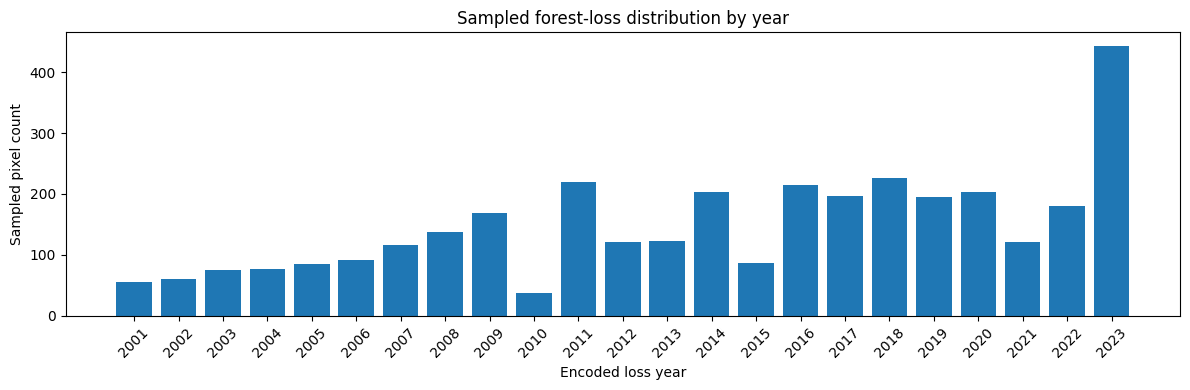

In [9]:

# FD01 Cell 10 — Loss distribution by year

lossyear = sampled_layers["lossyear"]

valid_loss = lossyear[(lossyear >= 1) & (lossyear <= 23)]

year_counts = pd.DataFrame({
    "year": 2000 + np.arange(1, 24),
    "sampled_loss_pixels": [
        int(np.count_nonzero(valid_loss == year_code))
        for year_code in range(1, 24)
    ]
})

display(year_counts)

year_counts.to_csv(
    os.path.join(RESULTS_DIR, "FD01_loss_by_year.csv"),
    index=False
)

plt.figure(figsize=(12, 4))
plt.bar(year_counts["year"], year_counts["sampled_loss_pixels"])
plt.xlabel("Encoded loss year")
plt.ylabel("Sampled pixel count")
plt.title("Sampled forest-loss distribution by year")
plt.xticks(year_counts["year"], rotation=45)
plt.tight_layout()

plt.savefig(
    os.path.join(RESULTS_DIR, "FD01_loss_by_year.png"),
    dpi=160
)
plt.show()

In [10]:

# FD01 Cell 11 — Tree cover and loss cross-check

lossyear = sampled_layers["lossyear"]
treecover = sampled_layers["treecover2000"]

# Restrict to pixels with baseline canopy cover >= 30%.
# This is an exploratory threshold, not a universal forest definition.
baseline_forest = treecover >= 30
detected_loss = (lossyear >= 1) & (lossyear <= 23)

categories = {
    "Baseline canopy >= 30%": baseline_forest,
    "Detected loss year": detected_loss,
    "Baseline canopy >= 30% and detected loss": baseline_forest & detected_loss
}

for name, mask in categories.items():
    print(f"{name}: {int(np.count_nonzero(mask)):,} sampled pixels")

cross_check = pd.DataFrame([
    {
        "category": name,
        "sampled_pixels": int(np.count_nonzero(mask))
    }
    for name, mask in categories.items()
])

cross_check.to_csv(
    os.path.join(RESULTS_DIR, "FD01_treecover_loss_crosscheck.csv"),
    index=False
)

print("\nNote: canopy >= 30% is an exploratory filter, not ground truth.")

Baseline canopy >= 30%: 36,224 sampled pixels
Detected loss year: 3,440 sampled pixels
Baseline canopy >= 30% and detected loss: 1,972 sampled pixels

Note: canopy >= 30% is an exploratory filter, not ground truth.


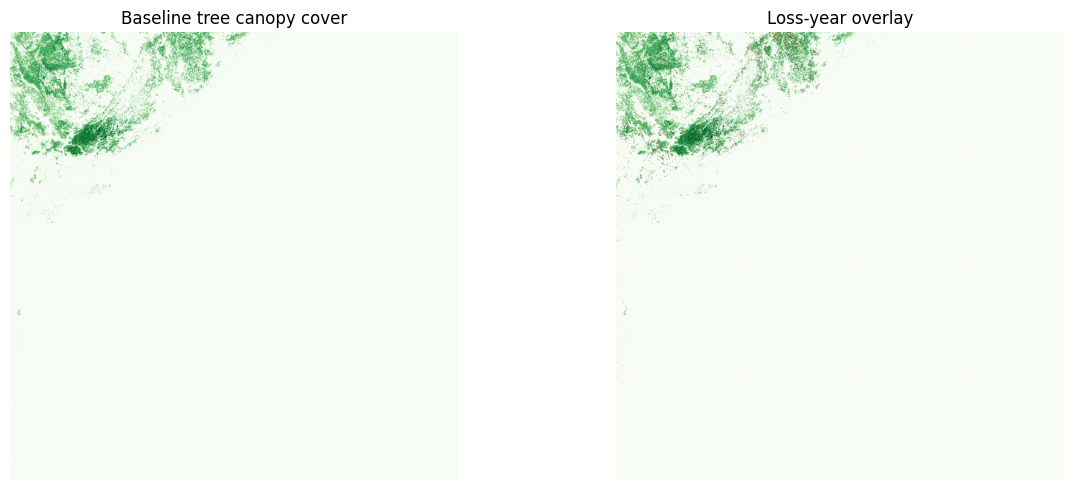

Saved: /content/forest_disturbance/results/FD01_loss_overlay.png


In [11]:

# FD01 Cell 12 — Display loss over baseline canopy cover

lossyear = sampled_layers["lossyear"]
treecover = sampled_layers["treecover2000"]

loss_mask = (lossyear >= 1) & (lossyear <= 23)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].imshow(treecover, cmap="Greens", vmin=0, vmax=100)
axes[0].set_title("Baseline tree canopy cover")
axes[0].axis("off")

axes[1].imshow(treecover, cmap="Greens", vmin=0, vmax=100)
overlay = np.ma.masked_where(~loss_mask, lossyear)
axes[1].imshow(overlay, cmap="autumn", vmin=1, vmax=23, alpha=0.8)
axes[1].set_title("Loss-year overlay")
axes[1].axis("off")

plt.tight_layout()

overlay_path = os.path.join(
    RESULTS_DIR, "FD01_loss_overlay.png"
)
plt.savefig(overlay_path, dpi=160, bbox_inches="tight")
plt.show()

print("Saved:", overlay_path)

In [12]:

# FD01 Cell 13 — Save observations for the research log

lossyear = sampled_layers["lossyear"]
treecover = sampled_layers["treecover2000"]

loss_count = int(np.count_nonzero((lossyear >= 1) & (lossyear <= 23)))
baseline_forest_count = int(np.count_nonzero(treecover >= 30))
overlap_count = int(np.count_nonzero(
    (treecover >= 30) & (lossyear >= 1) & (lossyear <= 23)
))

observations_path = os.path.join(
    RESULTS_DIR, "FD01_research_observations.md"
)

observations = f"""# FD01 — Research Observations

## Dataset examined

Hansen Global Forest Change GFC-2023-v1.11.

Selected tile: 20N_080E.

## Data inspection

- Tree-cover layer: `treecover2000`.
- Forest-loss layer: `lossyear`.
- Downsampled inspection grid: {lossyear.shape[0]} × {lossyear.shape[1]} pixels.
- Sampled pixels with an encoded loss year: {loss_count}.
- Sampled pixels with baseline canopy cover >= 30%: {baseline_forest_count}.
- Pixels meeting both exploratory conditions: {overlap_count}.

## Interpretation

These counts describe the sampled raster overview only. They are not
full-resolution area estimates and should not be interpreted as proof
of deforestation, illegality or human causation.

The 30% canopy-cover threshold is an exploratory filter, not a universal
definition of forest.

## Limitations

- A single tile does not represent global forest conditions.
- The loss layer is a derived satellite product, not raw imagery.
- Spatial patterns require geographic context and further validation.
- No model training or independent accuracy assessment was conducted.

## Next research decision

Determine whether the project will use this product for exploratory
analysis, or obtain suitable optical/radar imagery and independent
reference labels for a controlled forest-disturbance detection experiment.
"""

with open(observations_path, "w", encoding="utf-8") as f:
    f.write(observations)

print(observations)
print("\nSaved:", observations_path)

# FD01 — Research Observations

## Dataset examined

Hansen Global Forest Change GFC-2023-v1.11.

Selected tile: 20N_080E.

## Data inspection

- Tree-cover layer: `treecover2000`.
- Forest-loss layer: `lossyear`.
- Downsampled inspection grid: 1000 × 1000 pixels.
- Sampled pixels with an encoded loss year: 3440.
- Sampled pixels with baseline canopy cover >= 30%: 36224.
- Pixels meeting both exploratory conditions: 1972.

## Interpretation

These counts describe the sampled raster overview only. They are not
full-resolution area estimates and should not be interpreted as proof
of deforestation, illegality or human causation.

The 30% canopy-cover threshold is an exploratory filter, not a universal
definition of forest.

## Limitations

- A single tile does not represent global forest conditions.
- The loss layer is a derived satellite product, not raw imagery.
- Spatial patterns require geographic context and further validation.
- No model training or independent accuracy assessment w

In [13]:

# FD01 Cell 14 — Output verification

print("FD01 results directory:", RESULTS_DIR)

for filename in sorted(os.listdir(RESULTS_DIR)):
    path = os.path.join(RESULTS_DIR, filename)
    print(f"{filename} — {os.path.getsize(path):,} bytes")

required = [
    "FD01_raster_metadata.csv",
    "FD01_forest_layers.png",
    "FD01_loss_year_distribution.csv",
    "FD01_summary.txt",
    "FD01_loss_by_year.csv",
    "FD01_loss_by_year.png",
    "FD01_treecover_loss_crosscheck.csv",
    "FD01_loss_overlay.png",
    "FD01_research_observations.md"
]

missing = [
    name for name in required
    if not os.path.exists(os.path.join(RESULTS_DIR, name))
]

if missing:
    print("\nMissing outputs:")
    for name in missing:
        print("-", name)
else:
    print("\nAll expected FD01 outputs are present.")

FD01 results directory: /content/forest_disturbance/results
FD01_forest_layers.png — 1,140,066 bytes
FD01_loss_by_year.csv — 224 bytes
FD01_loss_by_year.png — 46,717 bytes
FD01_loss_overlay.png — 473,729 bytes
FD01_loss_year_distribution.csv — 587 bytes
FD01_raster_metadata.csv — 307 bytes
FD01_research_observations.md — 1,255 bytes
FD01_summary.txt — 1,020 bytes
FD01_treecover_loss_crosscheck.csv — 123 bytes

All expected FD01 outputs are present.


In [14]:

# FD01 — Final conclusion and experiment record

import os
import numpy as np
from datetime import datetime

cover = np.asarray(sampled_layers["treecover2000"])
loss = np.asarray(sampled_layers["lossyear"])

# Basic data checks on the sampled raster arrays
valid_cover = np.isfinite(cover) & (cover >= 0) & (cover <= 100)
valid_loss = np.isfinite(loss) & (loss >= 0) & (loss <= 23)

loss_pixels = loss[valid_loss]
cover_pixels = cover[valid_cover]

loss_detected = int(np.sum(loss_pixels > 0))
no_loss = int(np.sum(loss_pixels == 0))
canopy_30 = int(np.sum(cover_pixels >= 30))

year_counts = {}
for value in range(1, 24):
    count = int(np.sum(loss_pixels == value))
    if count > 0:
        year_counts[2000 + value] = count

conclusion = f"""# FD01 — Forest Disturbance Data Inspection: Conclusion

**Experiment:** FD01
**Dataset:** Hansen Global Forest Change, version 2023 v1.11
**Status:** Initial data inspection completed, subject to the quality checks below
**Generated:** {datetime.now().strftime("%Y-%m-%d %H:%M")}

## 1. Observations

- Tree-cover sample dimensions: {cover.shape}
- Loss-year sample dimensions: {loss.shape}
- Valid tree-cover sample pixels (0–100): {int(valid_cover.sum())}
- Valid loss-year sample pixels (0–23): {int(valid_loss.sum())}
- Sample pixels with a non-zero loss-year value: {loss_detected}
- Sample pixels with loss-year value 0: {no_loss}
- Sample pixels with tree cover of at least 30%: {canopy_30}

## 2. Interpretation

The treecover2000 layer represents estimated tree canopy cover in the year
2000. The lossyear layer records the year of detected tree-cover loss:
values 1–23 correspond to 2001–2023, while 0 indicates no recorded loss
during that period.

These layers support exploratory analysis of tree cover and recorded
tree-cover loss. They do not, by themselves, establish the cause of loss,
prove illegal deforestation, or identify a specific human activity.

## 3. Important limitations

- This experiment uses downsampled raster data for initial inspection.
- Pixel counts reported here are sample counts, not total land area.
- A 30% canopy threshold is exploratory and is not a universal forest definition.
- Tree-cover loss is not necessarily permanent deforestation.
- No ground-truth validation, predictive model, or detection-performance
  evaluation has been completed in FD01.
- Spatial alignment and raster metadata checks must pass before comparing
  the layers scientifically.

## 4. Conclusion

FD01 provides an initial descriptive inspection of the Hansen tree-cover
and loss-year layers and prepares the data for a later, reproducible
forest-disturbance experiment. The next step is to verify spatial
alignment, define a suitable study area and reference labels, and establish
a documented baseline before making detection or accuracy claims.

## 5. Loss-year counts in the sampled raster

""" + (
    "\n".join(f"- {year}: {count} sampled pixels" for year, count in sorted(year_counts.items()))
    if year_counts else
    "- No non-zero loss-year values were found in the valid sample."
)

output_path = os.path.join(RESULTS_DIR, "FD01_conclusion.md")
with open(output_path, "w", encoding="utf-8") as f:
    f.write(conclusion)

print(conclusion)
print(f"\nConclusion saved to: {output_path}")

# FD01 — Forest Disturbance Data Inspection: Conclusion

**Experiment:** FD01  
**Dataset:** Hansen Global Forest Change, version 2023 v1.11  
**Status:** Initial data inspection completed, subject to the quality checks below  
**Generated:** 2026-10-09 09:24

## 1. Observations

- Tree-cover sample dimensions: (1000, 1000)
- Loss-year sample dimensions: (1000, 1000)
- Valid tree-cover sample pixels (0–100): 1000000
- Valid loss-year sample pixels (0–23): 1000000
- Sample pixels with a non-zero loss-year value: 3440
- Sample pixels with loss-year value 0: 996560
- Sample pixels with tree cover of at least 30%: 36224

## 2. Interpretation

The treecover2000 layer represents estimated tree canopy cover in the year
2000. The lossyear layer records the year of detected tree-cover loss:
values 1–23 correspond to 2001–2023, while 0 indicates no recorded loss
during that period.

These layers support exploratory analysis of tree cover and recorded
tree-cover loss. They do not, by themselves, 